# Example visualizations from sns och plt documentation

Exploring visualizations that can be helpful with presenting results and analysis

https://seaborn.pydata.org/examples/index.html 


------

The first phase followed a 2×2×2 design in which two explainers, two prediction models, and two settings (with and without permitted_ranges) were combined. The purpose was to identify key patterns, limitations, and sensitivities in the counterfactual generation process.

In this phase, baseline models with standard parameters (300 trees) were used together with the following DiCE settings:
- total_CFs = 10
- stopping_threshold = 0.9
- posthoc_sparsity_param = 0.1
- maxiterations (genetic) = 500
- Permitted_ranges 

The Generation 1 experiments reveal clear differences between explainers, models, and the use of constraints. Random search showed the greatest variation and often produced implausible counterfactuals without constraints, especially with Random Forest. XGBoost was more stable in random search and achieved high validity in both settings, but still struggled with feasibility when constraints were absent. The genetic algorithm was consistently faster and more robust than random search, with short runtimes and high validity when constraints were applied. Without constraints, there were cases where validity was not achieved or changes were marginal. In summary, the results show that constraints are crucial for plausible counterfactuals, random search is sensitive to model choice and parameter settings, and the genetic algorithm is the most efficient and stable method given the data for this experiment. 

---

Table 3.3: Summary of Results – Generation 1  
--------------------------------------------------
| Explainer      | Model | Constraints | Validity | Feasibility | Time (s) | Comment                                                      |
|----------------|-------|-------------|----------|-------------|----------|--------------------------------------------------------------|
| random-search  | RF    | Yes         | Medium   | High        | 1028     | More stable but slow; some validity failures                 |
| random-search  | RF    | No          | Low      | Low         | 301      | Several implausible CFs; validity sometimes fails            |
| random-search  | XGB   | Yes         | High     | High        | 435      | Robust; mainly BMI adjustments                               |
| random-search  | XGB   | No          | High     | Medium      | 134      | Valid but often implausible CFs                              |
| genetic        | RF    | Yes         | High     | High        | 19       | Fast and stable; varied solutions                            |
| genetic        | RF    | No          | Medium   | Low         | 19       | Some validity failures; some implausible CFs                 |
| genetic        | XGB   | Yes         | Medium/High | High     | 9        | Fastest; one observation without validity                    |
| genetic        | XGB   | No          | Medium/Low | Low       | 11       | Marginal BMI changes insufficient for validity               |

## sns examples

### stacked histogram

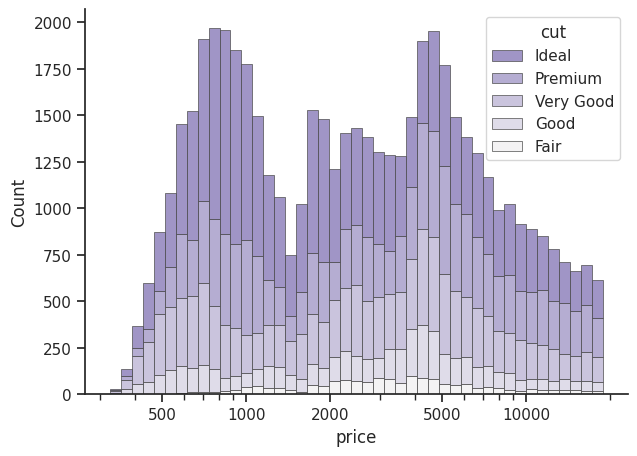

In [1]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

diamonds = sns.load_dataset("diamonds")

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    diamonds,
    x="price", hue="cut",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([500, 1000, 2000, 5000, 10000])

### facet grid

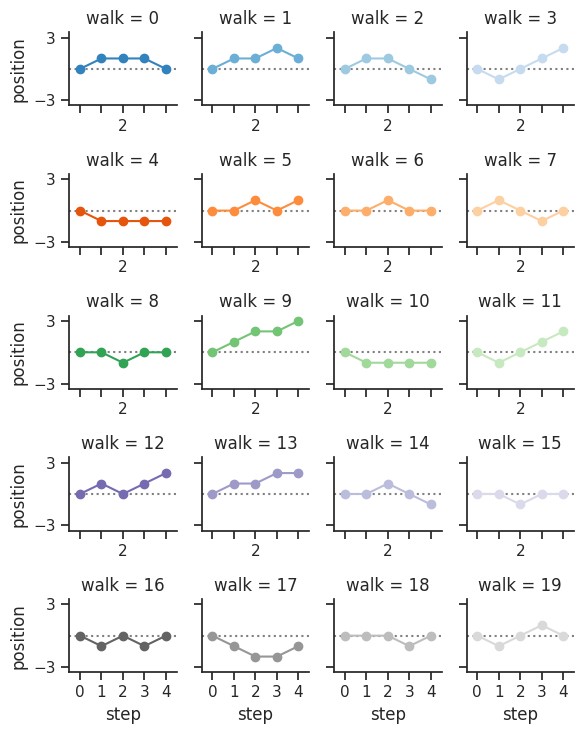

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Create a dataset with many short random walks
rs = np.random.RandomState(4)
pos = rs.randint(-1, 2, (20, 5)).cumsum(axis=1)
pos -= pos[:, 0, np.newaxis]
step = np.tile(range(5), 20)
walk = np.repeat(range(20), 5)
df = pd.DataFrame(np.c_[pos.flat, step, walk],
                  columns=["position", "step", "walk"])

# Initialize a grid of plots with an Axes for each walk
grid = sns.FacetGrid(df, col="walk", hue="walk", palette="tab20c",
                     col_wrap=4, height=1.5)

# Draw a horizontal line to show the starting point
grid.refline(y=0, linestyle=":")

# Draw a line plot to show the trajectory of each random walk
grid.map(plt.plot, "step", "position", marker="o")

# Adjust the tick positions and labels
grid.set(xticks=np.arange(5), yticks=[-3, 3],
         xlim=(-.5, 4.5), ylim=(-3.5, 3.5))

# Adjust the arrangement of the plots
grid.fig.tight_layout(w_pad=1)

<Axes: xlabel='year', ylabel='month'>

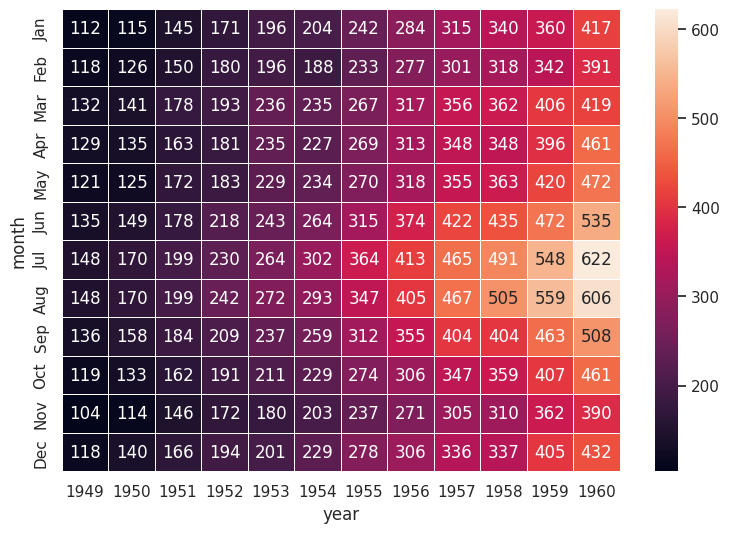

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Load the example flights dataset and convert to long-form
flights_long = sns.load_dataset("flights")
flights = (
    flights_long
    .pivot(index="month", columns="year", values="passengers")
)

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)